# 02 · Train and evaluate simple radiation models

Run after `01_Data_Preparation.ipynb`. This notebook compares a solar-elevation baseline, Random Forest, a Random Forest + isotonic dawn/dusk hybrid, and two small Histogram Gradient Boosting configurations. CPU only; fixed seed 42.

**Target:** historical station radiation (W/m²), not lux or the manual switching times. **Mode:** seasonal historical profile, with no current cloud forecast. Full implementation: `src/modeling.py`.

No score is a guarantee of switching accuracy. We inspect dawn and dusk separately because an overall score can be dominated by night-time zeros.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT/'config/project_config.json').exists():
    ROOT = ROOT/'LightSync'
assert (ROOT/'config/project_config.json').exists(), 'Open from the LightSync project folder.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
(ROOT/'reports/figures').mkdir(parents=True, exist_ok=True)


## 1. Inputs and chronological partitions

Training ends in August 2024; September is validation; October onward is held-out testing. Missing targets have already been removed, not imputed. All features are known calendar or solar geometry variables. Same-time weather and high-solar-radiation fields are excluded.

The baseline averages training radiation within 2-degree solar-elevation bins. It is a serious comparator: the solar trajectory explains much of the predictable daily pattern.

In [2]:
data = pd.read_parquet(ROOT/'data/processed/solar_model_input.parquet')
feature_config = json.loads((ROOT/'config/model_features.json').read_text())
display(data.groupby('split', sort=False).agg(rows=('timestamp_local','size'),
        start=('timestamp_local','min'), end=('timestamp_local','max')))
print('Features:', feature_config['features'])
assert data[feature_config['features']+['solar_radiation_w_m2']].notna().all().all()


,rows,start,end
split,,,
train,13840,2024-03-07 00:00:00+05:30,2024-08-31 23:45:00+05:30
validation,1820,2024-09-01 00:00:00+05:30,2024-09-29 03:15:00+05:30
test,4533,2024-10-01 07:45:00+05:30,2025-01-15 01:45:00+05:30


Features: ['minute_of_day', 'day_of_year', 'month', 'time_sin', 'time_cos', 'year_sin', 'year_cos', 'solar_elevation_deg']


## 2. Train and select on validation only

- Random Forest: 150 trees, maximum depth 12, minimum 10 observations per leaf.
- Dawn/dusk hybrid: the same forest with separate monotone low-sun curves fitted on training observations, blending back to the forest above 10–20 degrees. It remains a comparator unless validation improves.
- Histogram Gradient Boosting: 200 iterations, learning rate 0.05, 15 or 31 leaves, minimum 30 observations per leaf. Automatic random early stopping is disabled.
- Selection score: **70% low-sun MAE + 30% daytime MAE**, fixed before examining test results. Low sun means geometric solar elevation −6° to 15°.

This gives transition conditions more weight while retaining a daytime check. The baseline can win. The notebook reports every candidate, rather than selecting whichever happens to look best on the test set. The historical test has already been inspected in earlier prototype iterations; its reuse is a benchmark, not a new unseen field test.

,model,validation_score_w_m2,validation_daytime_mae_w_m2,validation_low_sun_mae_w_m2,training_seconds,selected
0,Random Forest,49.663,131.683,14.511,3.415,True
1,Random Forest + dawn/dusk curves,49.833,131.828,14.693,3.162,False
2,Elevation baseline,51.516,136.498,15.096,0.083,False
3,HistGradientBoosting 15 leaves,62.737,154.398,23.453,0.351,False
4,HistGradientBoosting 31 leaves,63.697,158.630,23.012,0.537,False


Selected: Random Forest


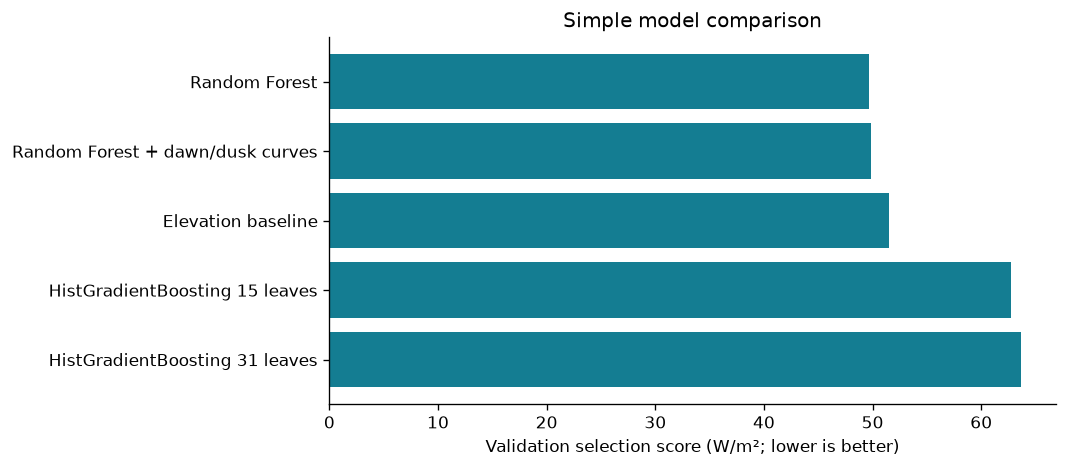

In [3]:
from src.modeling import train_models
leaderboard, test_metrics, card = train_models(ROOT)
display(leaderboard.round(3))
print('Selected:', card['selected_model'])
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(leaderboard.model, leaderboard.validation_score_w_m2, color='#147d92')
ax.invert_yaxis()
ax.set(xlabel='Validation selection score (W/m²; lower is better)', title='Simple model comparison')
fig.tight_layout()
fig.savefig(ROOT/'reports/figures/model_comparison.png')
plt.show()


## 3. Held-out results, including weak segments

MAE and RMSE are in W/m². R² may be negative: that means the model is worse than the segment's constant mean by this metric. A strong all-hours score does not establish strong dusk performance. We do not change model selection after looking at these results.

The saved `evaluation_model.joblib` is fitted on training only. After evaluation, a separate `demo_radiation_model.joblib` refits the selected model specification on all valid historical observations. The scores below do not evaluate that all-data refit.

In [4]:
selected_test = test_metrics[test_metrics.model.eq(card['selected_model'])]
display(selected_test.round(3))
display(test_metrics[test_metrics.segment.isin(['daytime','low_sun','dusk'])].round(3))
weak = selected_test[selected_test.r2.lt(0)]
if not weak.empty:
    print('Weak segments (negative R²):', ', '.join(weak.segment))
    print('Use scenario proposals only; local validation is needed before operational switching.')


,model,segment,n,mae_w_m2,rmse_w_m2,r2,bias_w_m2
6,Random Forest,all,4533,35.110,82.862,0.766,13.528
7,Random Forest,daytime,1771,89.503,132.563,0.568,34.277
8,Random Forest,low_sun,642,18.905,34.328,0.191,14.392
9,Random Forest,dawn,425,11.881,18.449,0.634,6.432
10,Random Forest,dusk,217,32.663,53.101,-0.250,29.982
11,Random Forest,night,2592,0.160,0.660,NaN,0.160


,model,segment,n,mae_w_m2,rmse_w_m2,r2,bias_w_m2
1,Elevation baseline,daytime,1771,120.541,156.478,0.399,-48.744
2,Elevation baseline,low_sun,642,15.457,25.245,0.562,-3.543
4,Elevation baseline,dusk,217,20.939,34.261,0.480,-16.818
7,Random Forest,daytime,1771,89.503,132.563,0.568,34.277
8,Random Forest,low_sun,642,18.905,34.328,0.191,14.392
10,Random Forest,dusk,217,32.663,53.101,-0.250,29.982
13,Random Forest + dawn/dusk curves,daytime,1771,86.537,131.130,0.578,26.812
14,Random Forest + dawn/dusk curves,low_sun,642,12.016,20.199,0.720,-3.072
16,Random Forest + dawn/dusk curves,dusk,217,13.077,22.463,0.776,-2.442
19,HistGradientBoosting 15 leaves,daytime,1771,96.972,132.336,0.570,-22.148


Weak segments (negative R²): dusk
Use scenario proposals only; local validation is needed before operational switching.


## 4. Prediction diagnostics

The scatter plot contains only held-out daylight observations. The daily plot uses the test day with the most available daylight samples, selected by coverage rather than lowest error. Missing observations are not filled.

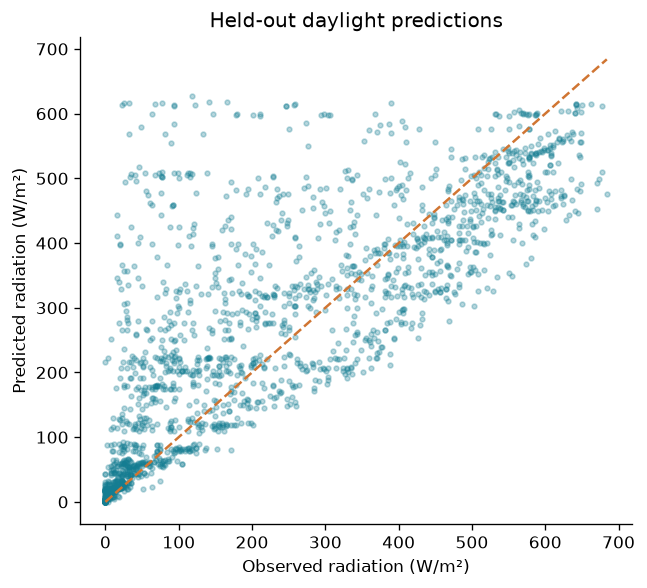

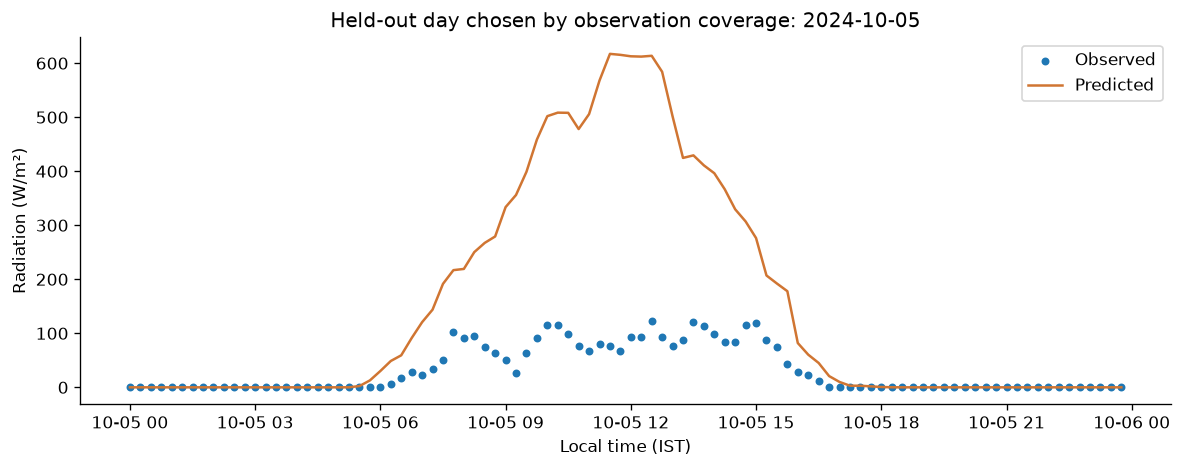

In [5]:
predictions = pd.read_parquet(ROOT/'reports/modeling/test_predictions.parquet')
pred = predictions[predictions.model.eq(card['selected_model'])].copy()
daylight = pred[pred.solar_elevation_deg.gt(0)]
fig, ax = plt.subplots(figsize=(5.5,5))
ax.scatter(daylight.solar_radiation_w_m2, daylight.predicted_radiation_w_m2, s=8, alpha=.3, color='#147d92')
limit = max(daylight.solar_radiation_w_m2.max(),daylight.predicted_radiation_w_m2.max())
ax.plot([0,limit],[0,limit],color='#d07532',linestyle='--')
ax.set(xlabel='Observed radiation (W/m²)',ylabel='Predicted radiation (W/m²)',title='Held-out daylight predictions')
fig.tight_layout()
fig.savefig(ROOT/'reports/figures/test_scatter.png')
plt.show()

day = daylight.groupby(daylight.timestamp_local.dt.strftime('%Y-%m-%d')).size().idxmax()
one_day = pred[pred.timestamp_local.dt.strftime('%Y-%m-%d').eq(day)]
fig, ax = plt.subplots(figsize=(10,4))
ax.scatter(one_day.timestamp_local.dt.tz_localize(None),one_day.solar_radiation_w_m2,label='Observed',s=14)
ax.plot(one_day.timestamp_local.dt.tz_localize(None),one_day.predicted_radiation_w_m2,label='Predicted',color='#d07532')
ax.set(title=f'Held-out day chosen by observation coverage: {day}',ylabel='Radiation (W/m²)',xlabel='Local time (IST)')
ax.legend()
fig.tight_layout()
fig.savefig(ROOT/'reports/figures/test_day.png')
plt.show()


## 5. Reproducibility checks

Check that inference feature construction matches the preparation notebook and that the saved evaluation model reproduces its saved test predictions. Only load model files you trust; these are local artifacts generated by this project.

In [6]:
import joblib
from src.modeling import make_features, predict_nonnegative
cfg = json.loads((ROOT/'config/project_config.json').read_text())
sample = data.iloc[::500].copy()
rebuilt = make_features(sample.timestamp_local, cfg)
np.testing.assert_allclose(rebuilt[feature_config['features']].to_numpy(),sample[feature_config['features']].to_numpy())
bundle = joblib.load(ROOT/'models/evaluation_model.joblib')
test = data[data.split.eq('test')]
np.testing.assert_allclose(predict_nonnegative(bundle['model'],test[bundle['features']]),pred.predicted_radiation_w_m2)
assert len(test)==len(pred)
print('Saved model and feature parity checks passed.')
print('Next: open 03_Lighting_and_Energy.ipynb')


Saved model and feature parity checks passed.
Next: open 03_Lighting_and_Energy.ipynb


## Interpretation

The historical model cannot know September 2026 clouds from the date alone. Exact location GPS, local lux calibration and installed fixture model confirmation remain outstanding. The next notebook demonstrates how a forecast could drive decisions under explicit daylight settings; it does not turn scenario settings into measured facts.

References: [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html), [Histogram Gradient Boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html).